# 04 — Slot Embeddings: Breaking Decoder Symmetry

## Hypothesis

A standard `MLPSetDecoder` generates all output slots from the same latent vector `z`. At initialisation, each slot's prediction is nearly identical (differing only by small random weight variation), placing all predictions at roughly the same centroid. The loss gradient is therefore nearly the same for every slot, and there is no force to differentiate them — a *centroid trap*.

`SlottedMLPSetDecoder` appends a learnable per-slot embedding `e_k` to `z` before decoding, so slot `k` receives input `[z; e_k]`. Even at random initialisation the embeddings break permutation symmetry: different slots see different inputs, so each slot receives a distinct gradient signal from the very first step.

**Prediction**: slotted decoders should escape the centroid trap faster (lower matched distance in early epochs) and achieve better final coverage, especially combined with the sharper Power-SM3 loss.

**Experiment**: 4 runs — {standard, slotted} × {Chamfer, Power-SM3 τ=0.12 p=3}.

In [1]:
import sys
sys.path.insert(0, '.')
import clevr_utils as cu
from influencerformer.losses import ChamferLoss, PowerSoftMinLoss
print(f'Device: {cu.DEVICE}')

Device: cuda


In [2]:
N_EPOCHS = 20
SNAPSHOT_EPOCHS = {0, 5, 15, 35, 49}

In [3]:
runs = [
    ('Chamfer (standard)', ChamferLoss(),                                    lambda: cu.make_model(slotted=False)),
    ('Chamfer (slotted)',  ChamferLoss(),                                    lambda: cu.make_model(slotted=True)),
    ('PM3 (standard)',     PowerSoftMinLoss(temperature=0.12, power=3.0),    lambda: cu.make_model(slotted=False)),
    ('PM3 (slotted)',      PowerSoftMinLoss(temperature=0.12, power=3.0),    lambda: cu.make_model(slotted=True)),
]

all_results = {}

for label, loss_fn, model_fn in runs:
    print(f'\n=== Training {label} ===')
    metrics, snapshots = cu.train_and_monitor(
        loss_fn,
        loss_name=label,
        model_fn=model_fn,
        n_epochs=N_EPOCHS,
        snapshot_epochs=SNAPSHOT_EPOCHS,
        tau_for_entropy=0.12,
    )
    all_results[label] = (metrics, snapshots)


=== Training Chamfer (standard) ===


/global/homes/d/danieltm/.conda/envs/influencer/lib/python3.11/site-packages/torch/nn/modules/transformer.py:296: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343970094/work/aten/src/ATen/NestedTensorImpl.cpp:177.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


  [Chamfer (standard)] epoch   0 | loss=3.3090 dist=1.6213 div=1.450 H=0.230 gd=0.735 lr=3.00e-04
  [Chamfer (standard)] epoch   1 | loss=2.9035 dist=1.5384 div=1.551 H=0.198 gd=0.629 lr=3.00e-04
  [Chamfer (standard)] epoch   2 | loss=2.6684 dist=1.4232 div=1.672 H=0.206 gd=0.715 lr=3.00e-04
  [Chamfer (standard)] epoch   3 | loss=2.4255 dist=1.3397 div=1.756 H=0.210 gd=0.689 lr=3.00e-04
  [Chamfer (standard)] epoch   4 | loss=2.2376 dist=1.2754 div=1.827 H=0.198 gd=0.824 lr=3.00e-04
  [Chamfer (standard)] epoch   5 | loss=2.0890 dist=1.2362 div=1.850 H=0.203 gd=0.791 lr=3.00e-04
  [Chamfer (standard)] epoch   6 | loss=1.9803 dist=1.1987 div=1.889 H=0.204 gd=0.709 lr=3.00e-04
  [Chamfer (standard)] epoch   7 | loss=1.8965 dist=1.1886 div=1.894 H=0.208 gd=0.795 lr=3.00e-04
  [Chamfer (standard)] epoch   8 | loss=1.8307 dist=1.1704 div=1.915 H=0.210 gd=0.791 lr=3.00e-04
  [Chamfer (standard)] epoch   9 | loss=1.7638 dist=1.1594 div=1.938 H=0.207 gd=0.798 lr=3.00e-04
  [Chamfer (standard

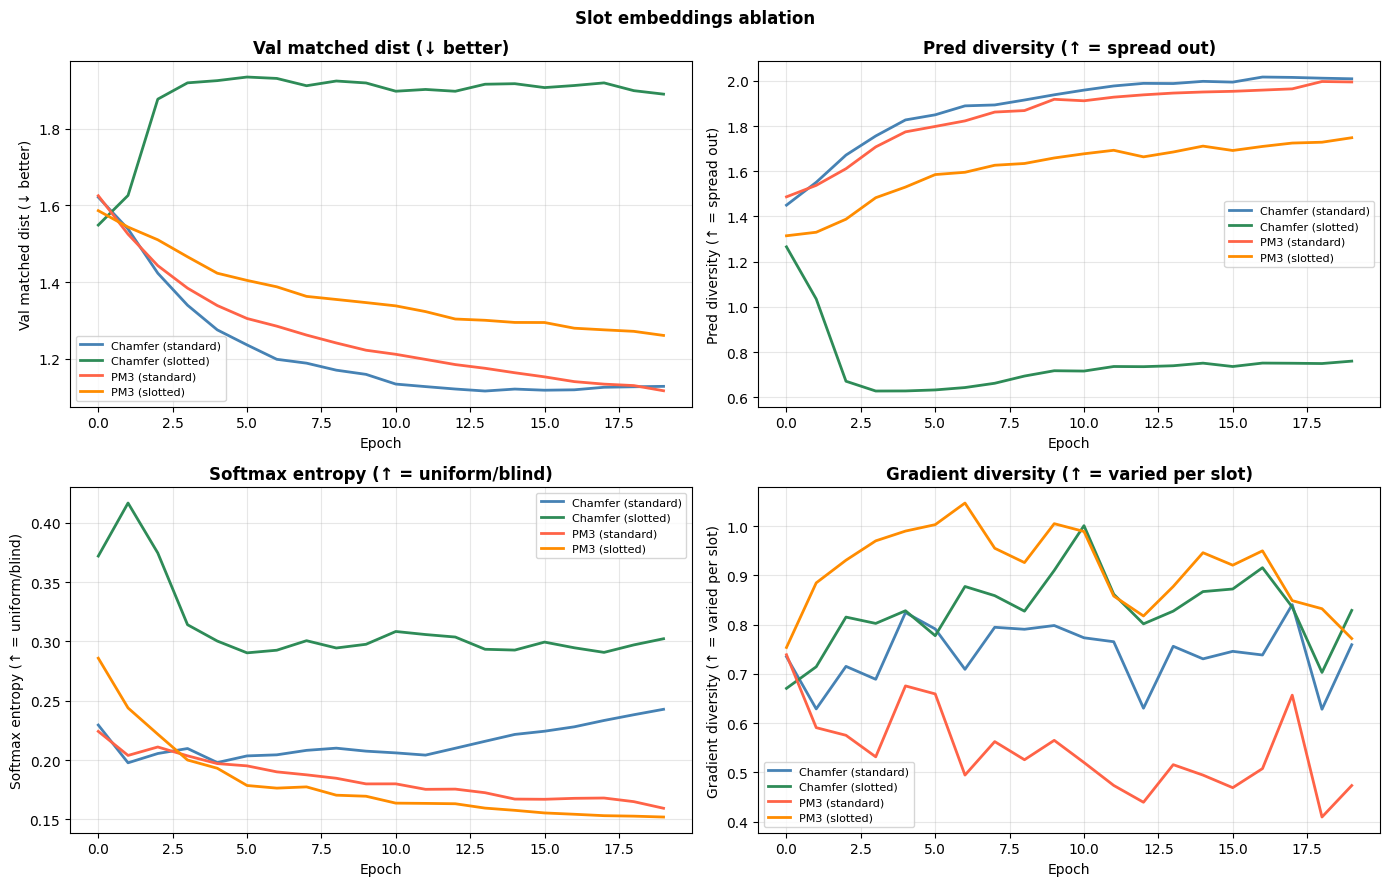

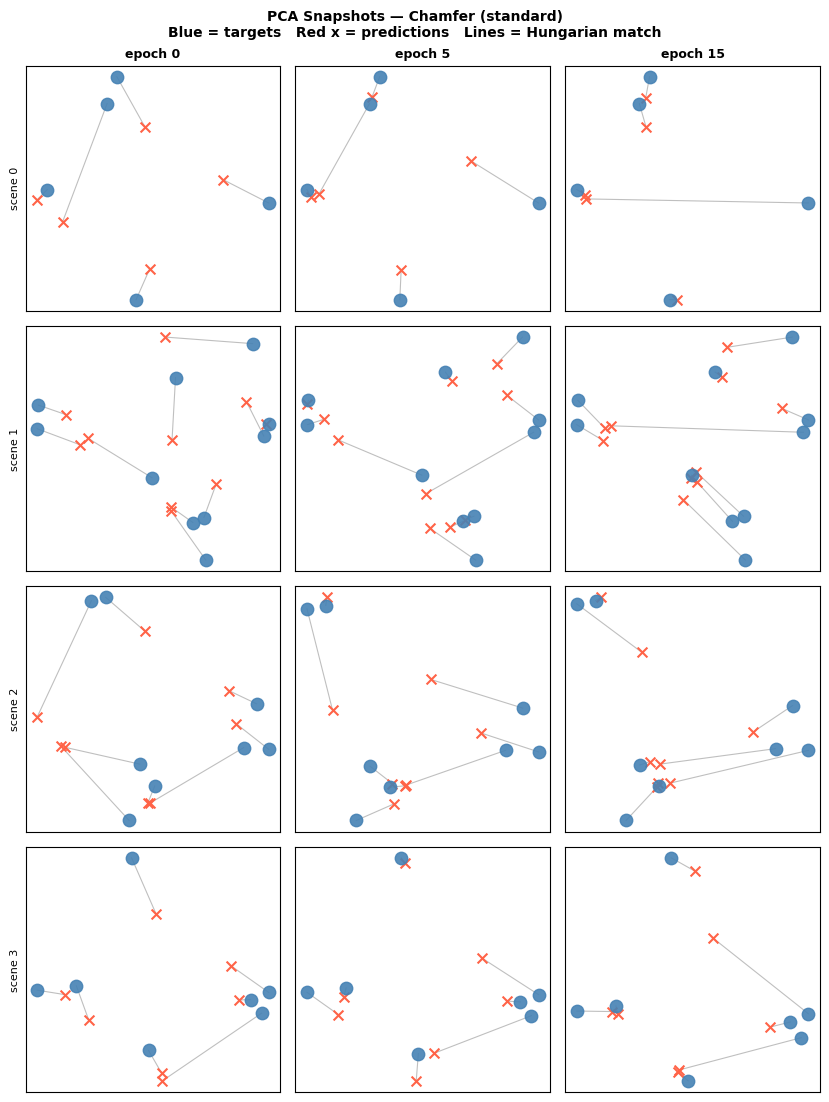

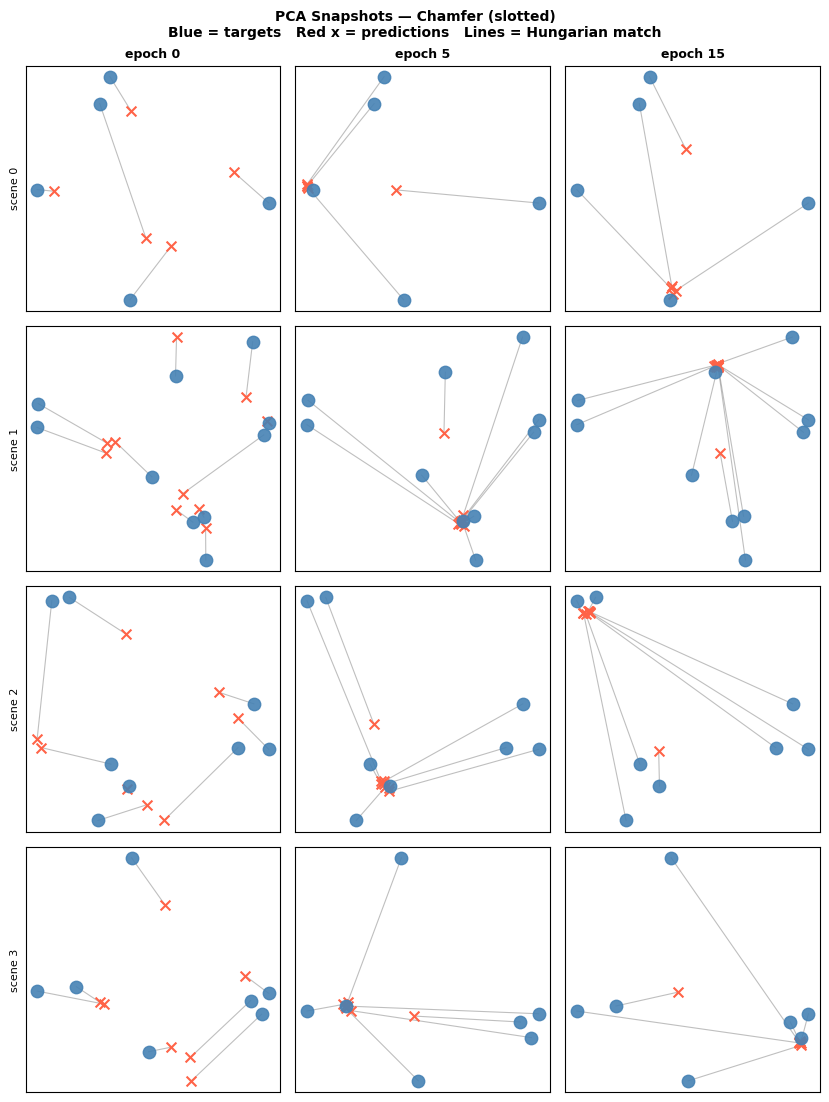

In [4]:
cu.plot_monitoring(all_results, title='Slot embeddings ablation')

cu.plot_pca_snapshots(
    all_results['Chamfer (standard)'][1],
    title='PCA Snapshots — Chamfer (standard)',
)
cu.plot_pca_snapshots(
    all_results['Chamfer (slotted)'][1],
    title='PCA Snapshots — Chamfer (slotted)',
)

In [5]:
cu.summary_table(all_results)

Name                           Final dist   Pred div   SM entropy   Grad div
----------------------------------------------------------------------------
PM3 (standard)                     1.1167     1.9952       0.1594     0.4733
Chamfer (standard)                 1.1282     2.0093       0.2428     0.7591
PM3 (slotted)                      1.2609     1.7485       0.1520     0.7717
Chamfer (slotted)                  1.8900     0.7600       0.3022     0.8289
